In [1]:
import mne
from pathlib import Path
import numpy as np

from ieeg_prep import utils

In [2]:
path_to_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/processed")
ied_file = "ied_results.npz"
ied_results = np.load(path_to_dir/ied_file)

In [3]:
print(ied_results.files)
ied_mask = ied_results["channels_above_rate"]
print(ied_mask.sum())

['spike_markers', 'channel_spike_counts', 'channel_spike_rates', 'channels_above_rate', 'ch_names', 'sfreq']
28


# EDF file format fixes

In [4]:
path_to_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw")
eeg_file = "sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf"
path_to_eeg = path_to_dir/eeg_file
csv_path = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub-EMOP0004_ses-ieeg1_atlas-CerebrAThomasMiddle_electrodes.csv")


In [5]:
raw = mne.io.read_raw_edf(path_to_eeg, preload=True)

Extracting EDF parameters from /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 11150015  =      0.000 ...  5444.343 secs...


/tmp/ipykernel_2388351/1845282016.py:1: RuntimeWarning: Omitted 6 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(path_to_eeg, preload=True)


In [6]:
raw = utils.rename_channels(raw, channel_names=[{"name":"RPuI","new_name":"RPul"}])
raw = utils.label_channels(raw)
raw = utils.add_coordinates(raw, csv_path)

In [7]:
ied_ch_names =  np.asarray(raw.copy().pick('seeg').ch_names)[ied_mask]
print(ied_ch_names)
print(ied_ch_names.shape)

['RAm1' 'RAm2' 'RAm3' 'RAm4' 'RAm5' 'RAm6' 'RAm7' 'RAm8' 'RAHc1' 'RAHc2'
 'RAHc3' 'RAHc4' 'RAHc5' 'RAHc6' 'RMiHc1' 'RMiHc2' 'RMiHc3' 'RTePo1'
 'RTePo2' 'RTePo3' 'RTePo4' 'RTePo5' 'REc1' 'RPHG1' 'RPHG2' 'RPHG3'
 'RPHG4' 'RPHG5']
(28,)


# Preprocessing Pipeline

### Step 0: Resample

Regev & Casto et. al (2025) do not do this,
but two of the Chang Lab papers they cite do

In [8]:
events = mne.find_events(raw, stim_channel=["TRIG"])
raw_resampled, events = raw.resample(400, events=events)


Finding events on: TRIG
4693 events found on stim channel TRIG
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12]


### Step 1: Identify bad channels

Significant Line Noise +5sd above the rest

In [9]:
import numpy as np
import mne
from mne.time_frequency import psd_array_welch

def find_line_noise_channels(
    raw,
    picks="seeg",
    line_freq=60,
    max_freq=180,
    peak_half_width=2.0,
    bg_inner_gap=3.0,
    bg_outer_width=10.0,
    threshold_sd=5.0,
    n_fft=4096,
):
    """
    Identify channels with excessive line noise using a harmonic-to-background ratio.

    Parameters
    ----------
    raw : mne.io.Raw
        Raw MNE object.
    picks : str | list
        Channels to evaluate.
    line_freq : float
        Base line frequency (60 in US, 50 in many other countries).
    max_freq : float
        Maximum harmonic frequency to include.
    peak_half_width : float
        Half-width (Hz) around each harmonic treated as the noise peak.
    bg_inner_gap : float
        Gap (Hz) between peak band and background bands.
    bg_outer_width : float
        Width (Hz) of each background side band.
    threshold_sd : float
        Channels above mean + threshold_sd * std are flagged.
    n_fft : int
        Welch FFT length.

    Returns
    -------
    scores : dict
        Per-channel harmonic noise scores.
    bads : list
        Channels exceeding threshold.
    threshold : float
        Detection threshold.
    """
    data = raw.get_data(picks=picks)
    sfreq = raw.info["sfreq"]
    ch_names = np.array(raw.copy().pick(picks).ch_names)

    psds, freqs = psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=1,
        fmax=max_freq + bg_outer_width + 5,
        n_fft=n_fft,
        average="mean",
        verbose=False,
    )

    # Avoid log(0)
    psds = np.maximum(psds, np.finfo(float).eps)

    harmonics = np.arange(line_freq, max_freq + 0.1, line_freq)
    total_score = np.zeros(len(ch_names), dtype=float)

    for h in harmonics:
        peak_band = (freqs >= h - peak_half_width) & (freqs <= h + peak_half_width)

        left_bg = (freqs >= h - bg_inner_gap - bg_outer_width) & (freqs < h - bg_inner_gap)
        right_bg = (freqs > h + bg_inner_gap) & (freqs <= h + bg_inner_gap + bg_outer_width)
        bg_band = left_bg | right_bg

        if not peak_band.any() or not bg_band.any():
            continue

        peak_power = psds[:, peak_band].mean(axis=1)
        bg_power = psds[:, bg_band].mean(axis=1)

        # Ratio score; log makes it more stable
        harmonic_score = np.log10(peak_power / bg_power)
        total_score += harmonic_score

    mean_score = total_score.mean()
    std_score = total_score.std()
    threshold = mean_score + threshold_sd * std_score

    bad_mask = total_score > threshold
    bads = ch_names[bad_mask].tolist()

    scores = dict(zip(ch_names, total_score))
    return scores, bads, threshold

In [10]:
scores, bads, threshold = find_line_noise_channels(raw, picks="seeg")

In [11]:
bads

[]

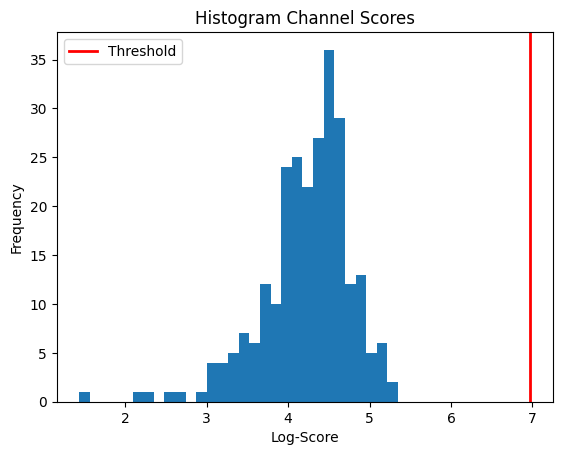

In [12]:
import matplotlib.pyplot as plt
import numpy as np

vals = np.asarray(list(scores.values()))

plt.hist(vals, bins=30)

plt.axvline(threshold, color="red", linewidth=2, label="Threshold")

plt.xlabel("Log-Score")
plt.ylabel("Frequency")
plt.title("Histogram Channel Scores")
plt.legend()

plt.show()

Declare bade electrodes


In [13]:
#High line noise bads
raw.info["bads"].extend([ch for ch in bads if ch not in raw.info["bads"]])

#IED bads
ch_names = np.array(raw.copy().pick('seeg').ch_names)
ied_bads = ch_names[ied_mask]
raw.info["bads"].extend([ch for ch in ied_bads if ch not in raw.info["bads"]])

In [14]:
raw.info

<Info | 10 non-empty values
 bads: 28 items (RAm1, RAm2, RAm3, RAm4, RAm5, RAm6, RAm7, RAm8, RAHc1, ...)
 ch_names: LAm1, LAm2, LAm3, LAm4, LAm5, LAm6, LAm7, LAm8, LAm9, LAm10, ...
 chs: 255 sEEG, 1 ECG, 19 misc, 1 Stimulus
 custom_ref_applied: False
 dig: 255 items (255 EEG)
 highpass: 0.0 Hz
 lowpass: 200.0 Hz
 meas_date: 2001-06-24 15:35:53 UTC
 nchan: 276
 projs: []
 sfreq: 400.0 Hz
 subject_info: <subject_info | his_id: sub-EMOP0004, sex: 0, last_name: X>
>

### Step 2:  Filtering

high pass filter of 0.5hz

In [15]:
raw.filter(l_freq=0.5, h_freq=None, picks="seeg",phase="zero")

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 2641 samples (6.603 s)



<RawEDF | sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf, 276 x 2177738 (5444.3 s), ~4.48 GiB, data loaded>

IIR Notch filter @ 60Hz (US Line frequency) and Harmonics under 200hz 

In [16]:
freqs = [60,120,180]

for f in freqs:
    raw.notch_filter(
        freqs=f,
        method="iir",
        picks="seeg"
    )

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 59.35, 60.65 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 1.2e+02 - 1.2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 119.20, 120.80 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 1.8e+02 - 1.8e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 179.05, 180.95 Hz: -6.02, -6.02 dB



Using matplotlib as 2D backend.


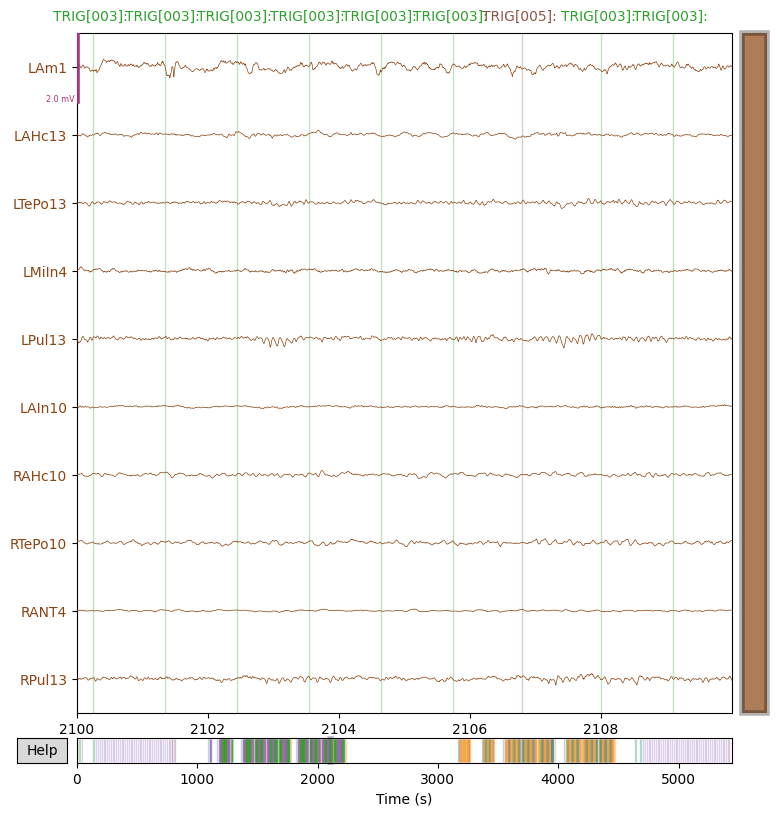

In [17]:
# before filtering
raw.plot(
    picks=raw.ch_names[0:250:25],
    duration=10,   # seconds shown at once
    start=2100,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 100e-5}
);

### Step 3: Common Average Referencing

In [18]:
 raw_car = raw.copy().set_eeg_reference(ref_channels="average", ch_type="seeg")

Applying average reference.
Applying a custom ('sEEG',) reference.


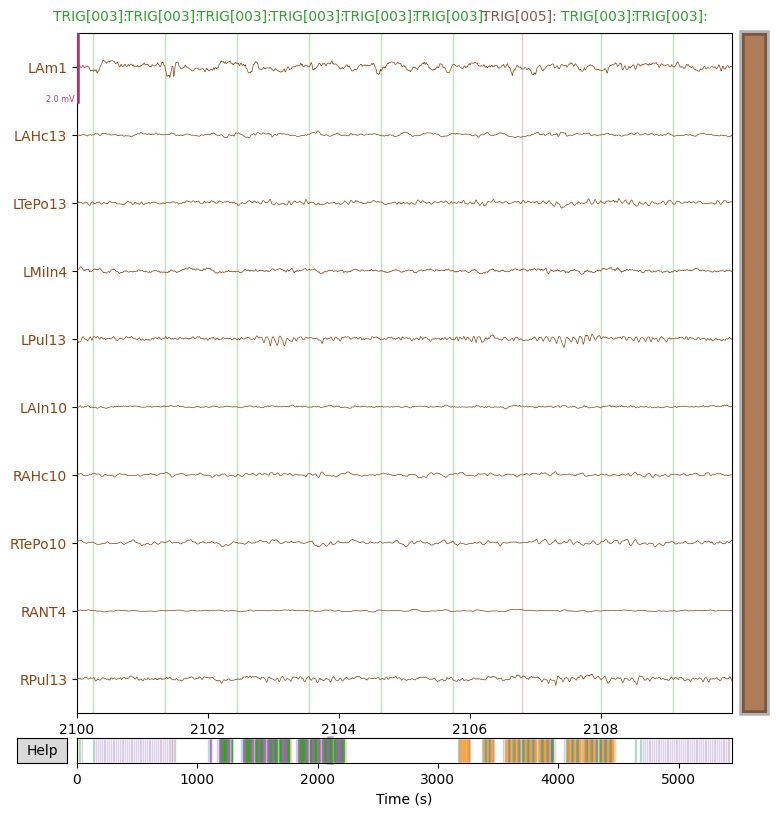

In [19]:
# before filtering
raw_car.plot(
    picks=raw_car.ch_names[0:250:25],
    duration=10,   # seconds shown at once
    start=2100,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 100e-5}
);

### step 4: Hilbert Transform


In [20]:
import numpy as np
import mne
from scipy.signal import hilbert


def high_gamma_envelope_gaussian_bank(
    raw,
    picks="seeg",
    center_freqs=(73, 79.5, 87.8, 96.9, 107, 118.1, 130.4, 144),
    sigmas=(4.68, 4.92, 5.17, 5.43, 5.7, 5.99, 6.3, 6.62),
    output="mean",  # "mean" or "all"
    ch_type_out="misc",
):
    """
    Compute high-gamma envelope using the paper's Gaussian filter bank + Hilbert pipeline.

    Steps:
    1. Apply Gaussian filter in frequency domain for each center frequency
    2. Inverse FFT back to time domain
    3. Compute analytic signal with Hilbert transform
    4. Take absolute value to get envelope
    5. Average envelopes across filters

    Parameters
    ----------
    raw : mne.io.BaseRaw
        Input raw object.
    picks : str | list
        Channels to process, e.g. "seeg".
    center_freqs : tuple/list of float
        Gaussian filter center frequencies in Hz.
    sigmas : tuple/list of float
        Gaussian SDs in Hz, same length as center_freqs.
    output : str
        "mean" -> return only averaged high-gamma envelope
        "all"  -> return one output channel per (channel x filter)
    ch_type_out : str
        Channel type for output RawArray. "misc" is usually safest.

    Returns
    -------
    hg_raw : mne.io.RawArray
        Output raw containing high-gamma envelope(s).
    envelopes : np.ndarray
        Array of shape (n_channels, n_filters, n_times)
        containing each filter-specific envelope.
    """
    center_freqs = np.asarray(center_freqs, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)

    if len(center_freqs) != len(sigmas):
        raise ValueError("center_freqs and sigmas must have the same length")

    raw_pick = raw.copy().pick(picks)
    data = raw_pick.get_data()  # shape: (n_channels, n_times)
    sfreq = raw_pick.info["sfreq"]
    ch_names = raw_pick.ch_names

    n_channels, n_times = data.shape
    n_filters = len(center_freqs)

    # FFT along time axis
    freqs = np.fft.rfftfreq(n_times, d=1.0 / sfreq)
    data_fft = np.fft.rfft(data, axis=1)

    # store per-filter envelopes
    envelopes = np.empty((n_channels, n_filters, n_times), dtype=np.float64)

    for k, (f0, sigma) in enumerate(zip(center_freqs, sigmas)):
        # Gaussian frequency response
        gaussian = np.exp(-0.5 * ((freqs - f0) / sigma) ** 2)

        # apply filter in frequency domain
        filtered_fft = data_fft * gaussian[None, :]

        # back to time domain
        filtered = np.fft.irfft(filtered_fft, n=n_times, axis=1)

        # analytic signal -> envelope
        analytic = hilbert(filtered, axis=1)
        envelope = np.abs(analytic)

        envelopes[:, k, :] = envelope

    if output == "mean":
        hg_data = envelopes.mean(axis=1)  # shape: (n_channels, n_times)
        out_ch_names = [f"{ch}_hg" for ch in ch_names]
    elif output == "all":
        hg_data = envelopes.reshape(n_channels * n_filters, n_times)
        out_ch_names = [
            f"{ch}_hg_{cf:g}" for ch in ch_names for cf in center_freqs
        ]
    else:
        raise ValueError("output must be 'mean' or 'all'")

    info_out = mne.create_info(
        ch_names=out_ch_names,
        sfreq=sfreq,
        ch_types=[ch_type_out] * len(out_ch_names),
    )

    hg_raw = mne.io.RawArray(hg_data, info_out)
    return hg_raw, envelopes

In [ ]:
hg_raw, envelopes = high_gamma_envelope_gaussian_bank(raw_car, picks="seeg")

In [ ]:
hg_raw.ch_names

In [ ]:
# before filtering
hg_raw.plot(
    picks=hg_raw.ch_names[0:250:25],
    duration=10,   # seconds shown at once
    start=2100,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 100e-5}
);



### Step 5: Linear Interpolation to replace outliers

In [ ]:
import numpy as np
import mne
from scipy.interpolate import PchipInterpolator


def remove_hg_outliers_pchip(
    hg_raw,
    picks=None,
    percentile=90,
    multiplier=5.0,
    output_dtype=np.float32,
    verbose=True,
):
    """
    Detect and replace envelope outliers channel-wise using PCHIP interpolation.

    Outlier rule for each channel:
        value > multiplier * percentile(channel, percentile)

    Parameters
    ----------
    hg_raw : mne.io.BaseRaw
        Raw object containing high-gamma envelope data.
    picks : None | str | list
        Channels to process. If None, process all channels.
    percentile : float
        Percentile used to define the baseline high value (default 90).
    multiplier : float
        Threshold multiplier applied to that percentile (default 5.0).
    output_dtype : dtype
        Output dtype for cleaned data.
    verbose : bool
        Whether to print summary information.

    Returns
    -------
    hg_clean_raw : mne.io.RawArray
        Cleaned RawArray with same channels and sfreq as input.
    outlier_mask : np.ndarray, shape (n_channels, n_times)
        Boolean mask of detected outliers.
    thresholds : np.ndarray, shape (n_channels,)
        Per-channel thresholds used.
    """
    raw_in = hg_raw.copy()

    if picks is not None:
        raw_in.pick(picks)

    data = raw_in.get_data().astype(np.float64, copy=True)
    ch_names = raw_in.ch_names
    sfreq = raw_in.info["sfreq"]
    n_channels, n_times = data.shape

    thresholds = multiplier * np.percentile(data, percentile, axis=1)
    outlier_mask = data > thresholds[:, None]

    x = np.arange(n_times)

    for ch in range(n_channels):
        bad = outlier_mask[ch]
        good = ~bad

        n_bad = bad.sum()

        if n_bad == 0:
            continue

        # Need at least 2 valid points to interpolate
        if good.sum() < 2:
            if verbose:
                print(f"{ch_names[ch]}: skipped (fewer than 2 non-outlier points)")
            continue

        # PCHIP interpolation from non-outlier points
        interpolator = PchipInterpolator(x[good], data[ch, good], extrapolate=True)
        data[ch, bad] = interpolator(x[bad])

        if verbose:
            pct = 100 * n_bad / n_times
            print(f"{ch_names[ch]}: replaced {n_bad} samples ({pct:.4f}%)")

    info_out = raw_in.info.copy()
    hg_clean_raw = mne.io.RawArray(data.astype(output_dtype, copy=False), info_out)

    return hg_clean_raw, outlier_mask, thresholds

In [ ]:
hg_clean_raw, outlier_mask, thresholds = remove_hg_outliers_pchip(
    hg_raw,
    percentile=90,
    multiplier=5.0,
    verbose=True,
)

In [ ]:
outlier_mask

In [ ]:
# before filtering
hg_clean_raw.plot(
    picks=hg_clean_raw.ch_names[0:250:25],
    duration=10,   # seconds shown at once
    start=2100,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 100e-5}
);

### Step 6: Downsample by a factor of 4

In [ ]:
new_frq = hg_clean_raw.info["sfreq"] // 4


In [ ]:
env_raw = hg_clean_raw.copy().resample(new_frq)

In [ ]:
# before filtering
env_raw.plot(
    picks=env_raw.ch_names[0:250:25],
    duration=10,   # seconds shown at once
    start=2100,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"seeg": 100e-5}
);

### Step 7: z-score and normalize -> downsample to 60 hz


In [ ]:
env_raw_data = env_raw.get_data().astype(np.float64, copy=True)

means = env_raw_data.mean(axis=1, keepdims=True)
stds = env_raw_data.std(axis=1, keepdims=True)
stds[stds == 0] = 1.0
env_raw_data_z = (env_raw_data - means) / stds

mins = env_raw_data_z.min(axis=1, keepdims=True)
maxs = env_raw_data_z.max(axis=1, keepdims=True)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
env_raw_data_norm = (env_raw_data_z - mins) / ranges

env_norm_raw = mne.io.RawArray(
    env_raw_data_norm.astype(np.float32),
    env_raw.info.copy()
)

env_norm_60_raw, events_60 = env_norm_raw.resample(60, events=events)

In [ ]:
# before filtering
env_norm_60_raw.plot(
    picks=env_norm_60_raw.ch_names[0:250:25],
    duration=10,   # seconds shown at once
    start=2100,       # start time in seconds
    n_channels=10,  # how many stacked traces
    scalings={"misc": 0.2}
);

### Step 8: save file

In [ ]:
#IED bads
ch_names = np.array(env_norm_60_raw.ch_names)
ied_bads = ch_names[ied_mask]
env_norm_60_raw.info["bads"].extend([ch for ch in ied_bads if ch not in env_norm_60_raw.info["bads"]])

env_norm_60_raw.info


In [ ]:
path_to_prep_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/processed")
prep_file = "EMOP0004_prep_raw.fif"
path_to_prep = path_to_prep_dir / prep_file


In [ ]:
env_norm_60_raw.save(path_to_prep, overwrite=True)

# Plotting

In [ ]:
seeg_picks = mne.pick_types(raw_out.info, seeg=True)
seeg_names = [raw_out.ch_names[i] for i in seeg_picks]

positions = montage.get_positions()["ch_pos"]

coordinates = np.array([positions[ch] for ch in seeg_names if ch in positions])

In [ ]:
coords = coordinates

# choose the cut location
cut_coords = (0, 0, 0)   # x, y, z

In [ ]:


display = plotting.plot_glass_brain(
    None,
    display_mode="ortho",
    title="Depth electrodes with depth-based opacity"
)

# unpack MNI coords
x = coords[:, 0]
y = coords[:, 1]
z = coords[:, 2]

# distance from each orthogonal plane
dx = np.abs(x - cut_coords[0])   # depth relative to sagittal plane
dy = np.abs(y - cut_coords[1])   # depth relative to coronal plane
dz = np.abs(z - cut_coords[2])   # depth relative to axial plane

# map distance -> alpha
# closer to the plane = more opaque
def dist_to_alpha(d, max_dist=30, min_alpha=0.3, max_alpha=1.0):
    a = max_alpha - (d / max_dist) * (max_alpha - min_alpha)
    return np.clip(a, min_alpha, max_alpha)

ax_alpha = dist_to_alpha(dx)   # for sagittal/x panel
cor_alpha = dist_to_alpha(dy)  # for coronal/y panel
axi_alpha = dist_to_alpha(dz)  # for axial/z panel

# small marker size
s = 12

# Nilearn display axes
ax_x = display.axes["x"].ax   # sagittal view
ax_y = display.axes["y"].ax   # coronal view
ax_z = display.axes["z"].ax   # axial view

# scatter directly onto each panel
# sagittal plane shows y vs z
for yi, zi, a in zip(y, z, ax_alpha):
    ax_x.scatter(yi, zi, s=s, c="blue", alpha=a)

# coronal plane shows x vs z
for xi, zi, a in zip(x, z, cor_alpha):
    ax_y.scatter(xi, zi, s=s, c="blue", alpha=a)

# axial plane shows x vs y
for xi, yi, a in zip(x, y, axi_alpha):
    ax_z.scatter(xi, yi, s=s, c="blue", alpha=a)

plt.show()
plt.close()

In [ ]:
display = plotting.plot_glass_brain(
    None,
    display_mode="ortho",
    title="Depth electrodes with depth-based opacity"
)


# Nilearn display axes
ax_x = display.axes["x"].ax   # sagittal view
ax_y = display.axes["y"].ax   # coronal view
ax_z = display.axes["z"].ax   # axial view

# scatter directly onto each panel
# sagittal plane shows y vs z

# unpack MNI coords
x = coords[ied_mask, 0]
y = coords[ied_mask, 1]
z = coords[ied_mask, 2]

for yi, zi, a in zip(y, z, ax_alpha[ied_mask]):
    ax_x.scatter(yi, zi, s=s, c="red", alpha=a)

# coronal plane shows x vs z
for xi, zi, a in zip(x, z, cor_alpha[ied_mask]):
    ax_y.scatter(xi, zi, s=s, c="red", alpha=a)

# axial plane shows x vs y
for xi, yi, a in zip(x, y, axi_alpha[ied_mask]):
    ax_z.scatter(xi, yi, s=s, c="red", alpha=a)
    
# unpack MNI coords
x = coords[~ied_mask, 0]
y = coords[~ied_mask, 1]
z = coords[~ied_mask, 2]
    
for yi, zi, a in zip(y, z, ax_alpha[~ied_mask]):
    ax_x.scatter(yi, zi, s=s, c="green", alpha=a)

# coronal plane shows x vs z
for xi, zi, a in zip(x, z, cor_alpha[~ied_mask]):
    ax_y.scatter(xi, zi, s=s, c="green", alpha=a)

# axial plane shows x vs y
for xi, yi, a in zip(x, y, axi_alpha[~ied_mask]):
    ax_z.scatter(xi, yi, s=s, c="green", alpha=a)

plt.show()